In [1]:
import os
import pickle
import mlflow
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import scikit_posthocs as sp
import matplotlib.pyplot as plt

from tqdm import tqdm
from numpy import sort
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from mlflow.models.signature import infer_signature
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import scale, StandardScaler
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from xgboost import XGBClassifier, plot_importance, XGBRFClassifier
from sklearn.linear_model import LogisticRegression
from scipy.stats import friedmanchisquare
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
from aeon.visualisation import plot_critical_difference

In [2]:
files = ['two_class_raw_1s_no.csv', 'two_class_raw_1s_yo_0.5.csv', 'two_class_raw_1s_yo_0.8.csv', 'two_class_raw_2s_no.csv', 'two_class_raw_2s_yo_0.5.csv', 'two_class_raw_2s_yo_0.8.csv', 
        'two_class_raw_3s_no.csv', 'two_class_raw_3s_yo_0.5.csv', 'two_class_raw_3s_yo_0.8.csv', 'two_class_raw_4s_no.csv', 'two_class_raw_4s_yo_0.5.csv', 'two_class_raw_4s_yo_0.8.csv',
        'two_class_raw_5s_no.csv', 'two_class_raw_5s_yo_0.5.csv', 'two_class_raw_5s_yo_0.8.csv']

base_path = '/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/improved_features_data_main/'

In [ ]:
results = []

scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro')
}

for file in files:
    data_path = os.path.join(base_path, file)
    features = pd.read_csv(data_path)
    features.drop(['center_time', 'start_time', 'end_time'], axis=1, inplace=True)
    
    # Extracting the experiment_id from the filename
    details = file.split('_')
    win_overlap = f"{details[3]}_{details[-1].replace('.csv', '')}"
    
    # Split features and labels    
    X = features.drop(columns=['label', 'experiment_id'])
    y = features['label']
    groups = features['experiment_id']

    # Split the data into training and testing sets  
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(splitter.split(X, y, groups))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]
    
    # Encode labels
    label_encoder = LabelEncoder()
    # Encode y_test and y_train
    y_train_encoded = label_encoder.fit_transform(y_train) 
    y_test_encoded = label_encoder.transform(y_test)
    
    gkf = GroupKFold(n_splits=10)
    
    models = [
    DecisionTreeClassifier(random_state=42),
    RandomForestClassifier(random_state=42),
    XGBClassifier(random_state=42, seed=42, n_estimators =100)
    ]

    for model in models:
        
        cv_scores = cross_val_score(model, X_train, y_train_encoded, groups=groups_train, cv=gkf, scoring='accuracy')
        
        mean_cv_score = round(np.mean(cv_scores) * 100, 2)
        std_cv_score = round(np.std(cv_scores) * 100, 2)
        var_cv_score = round(np.var(cv_scores) * 100, 2)
        
        results.append({
            'data_set': win_overlap,
            'model': model.__class__.__name__,
            'cv_score': mean_cv_score,
            'std_cv_score': std_cv_score,
            'var_cv_score': var_cv_score
        })

AttributeError: 'super' object has no attribute '__sklearn_tags__'

In [ ]:
# df = pd.DataFrame(results)
# df.head()

In [ ]:
# df.to_csv('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/baseline_analysis/baseline_comparison_results_main.csv', index=False)
df = pd.read_csv('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/baseline_analysis/baseline_comparison_results_main_check.csv')
df.head()

,data_set,model,cv_score,std_cv_score,var_cv_score
0,1s_no,DecisionTreeClassifier,61.33,7.21,0.52
1,1s_no,RandomForestClassifier,69.09,4.71,0.22
2,1s_no,XGBClassifier,66.34,4.51,0.20
3,1s_0.5,DecisionTreeClassifier,59.93,6.05,0.37
4,1s_0.5,RandomForestClassifier,69.54,7.82,0.61


In [ ]:
pivot_df = df.pivot(index='data_set', columns='model', values='cv_score')
pivot_df.to_csv('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/baseline_analysis/pivot_baseline_comparison_results_pivot_check.csv', index=True)
pivot_df.head()

model,DecisionTreeClassifier,RandomForestClassifier,XGBClassifier
data_set,,,
1s_0.5,59.93,69.54,64.74
1s_0.8,60.58,67.83,64.74
1s_no,61.33,69.09,66.34
2s_0.5,61.25,71.10,66.21
2s_0.8,62.54,70.93,67.03


In [ ]:
# Extract accuracy values for each model
model_scores = [pivot_df[model].values for model in pivot_df.columns]

# Run Friedman test
stat, p_value = friedmanchisquare(*model_scores)
# print(f"Friedman test p-value: {p_value}")

print(f"Friedman Statistic = {stat:.3f}, p = {p_value:.5f}")

if p_value < 0.05:
    print("✅ Reject H₀: Significant differences exist between models.")
else:
    print("❌ Fail to reject H₀: No significant differences.")

Friedman Statistic = 30.000, p = 0.00000
✅ Reject H₀: Significant differences exist between models.


In [ ]:
# Stack scores into a matrix (rows=folds, columns=models)
scores_matrix = np.column_stack([model_scores[0], model_scores[1], model_scores[2]])

# Nemenyi test
nemenyi_results = sp.posthoc_nemenyi_friedman(scores_matrix)
# print("Nemenyi p-values:\n", nemenyi_results)
nemenyi_results

,0,1,2
0,1.000000e+00,1.294636e-07,0.016979
1,1.294636e-07,1.000000e+00,0.016979
2,1.697928e-02,1.697928e-02,1.000000


In [ ]:
import scikit_posthocs as sp
import matplotlib.pyplot as plt

# Your Nemenyi p-value matrix
nemenyi_results = np.array([
    [1.0, 1.29e-07, 0.016979],
    [1.29e-07, 1.0, 0.016979],
    [0.016979, 0.016979, 1.0]
])

# Plot heatmap of p-values
sp.plot_pvalues(nemenyi_results)
plt.title("Nemenyi Test P-Values")
plt.show()

AttributeError: module 'scikit_posthocs' has no attribute 'plot_pvalues'

In [ ]:
# import matplotlib.pyplot as plt

# # Average ranks (1=best, 3=worst)
# avg_ranks = [1.2, 1.8, 2.5]  # Example: RandomForest=1.2, XGBoost=1.8, Logistic=2.5

# # Plot CD diagram
# sp.critical_difference_diagram(avg_ranks, sig_matrix=scores_matrix)
# plt.title("Critical Difference Diagram (Nemenyi)")
# plt.show()

In [ ]:
# Convert the accuracy matrix into a NumPy array for the critical difference diagram
# scores = df[algorithms].values
# classifiers = df[algorithms].columns.tolist()
# scores = df['cv_score'].values  # Use the cv_score column for accuracy values
# classifiers = df['model'].unique()

# print("Algorithms:", classifiers)
# print("Errors:", scores)

# # Set the figure size before plotting
# plt.figure(figsize=(16, 12))  # Adjust the figure size as needed

# # Generate the critical difference diagram
# plot_critical_difference(
#     scores, 
#     classifiers, 
#     lower_better=False, # in accuracy, higher is better
#     test='wilcoxon',  # or nemenyi
#     correction='holm', # or bonferroni or none
)

Algorithms: ['DecisionTreeClassifier' 'RandomForestClassifier' 'XGBClassifier']
Errors: [61.33 69.09 66.34 59.93 69.54 64.74 60.58 67.83 64.74 60.7  70.56 67.89
 61.25 71.1  66.21 62.54 70.93 67.03 63.66 70.43 67.85 60.45 70.9  66.94
 60.01 70.23 66.34 65.44 70.45 66.37 61.12 71.26 67.92 60.76 69.11 66.79
 60.81 70.61 67.02 58.47 71.97 68.2  60.99 70.23 67.47]


ValueError: not enough values to unpack (expected 2, got 1)

<Figure size 1600x1200 with 0 Axes>

In [ ]:
plt.figure(figsize=(10, 4))
plt.axis('off')  # Hide axes
table = plt.table(
    cellText=pivot_df.round(2).values,
    colLabels=pivot_df.columns,
    rowLabels=pivot_df.index,
    loc='center',
    cellLoc='center',
    colColours=['#f0f0f0']*len(pivot_df.columns)
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)
plt.savefig('cv_scores_table.png', bbox_inches='tight', dpi=300)
plt.close()

Error Table (%) with Ranking:
                     Dataset  NaiveBayes         IBk         J48 RandomForest  \
0                      MNIST  0.697 (11)   0.969 (5)   0.893 (9)    0.965 (6)   
1              Fashion-MNIST  0.633 (11)   0.856 (8)   0.817 (9)    0.881 (5)   
2                  e1-Spiral  0.709 (13)   0.996 (3)   0.978 (7)    0.982 (5)   
3                 e1-Android  0.919 (12)  0.923 (11)   0.953 (7)    0.955 (6)   
4              e2-andorinhas  0.919 (13)  0.934 (12)  0.944 (11)   0.951 (10)   
5                 e2-chinese  0.728 (11)   0.871 (9)  0.651 (13)    0.925 (7)   
6                    e3-user     1.0 (1)  0.951 (15)     1.0 (1)      1.0 (1)   
7               e3-ecommerce  0.886 (13)  0.888 (12)   0.976 (5)    0.979 (4)   
8                    e4-wine    0.55 (8)   0.648 (2)   0.614 (4)    0.701 (1)   
9                   e4-heart   0.565 (5)  0.534 (11)   0.642 (2)    0.628 (4)   
10              e5-mamiferos     1.0 (1)     1.0 (1)     1.0 (1)      1.0 (1)  

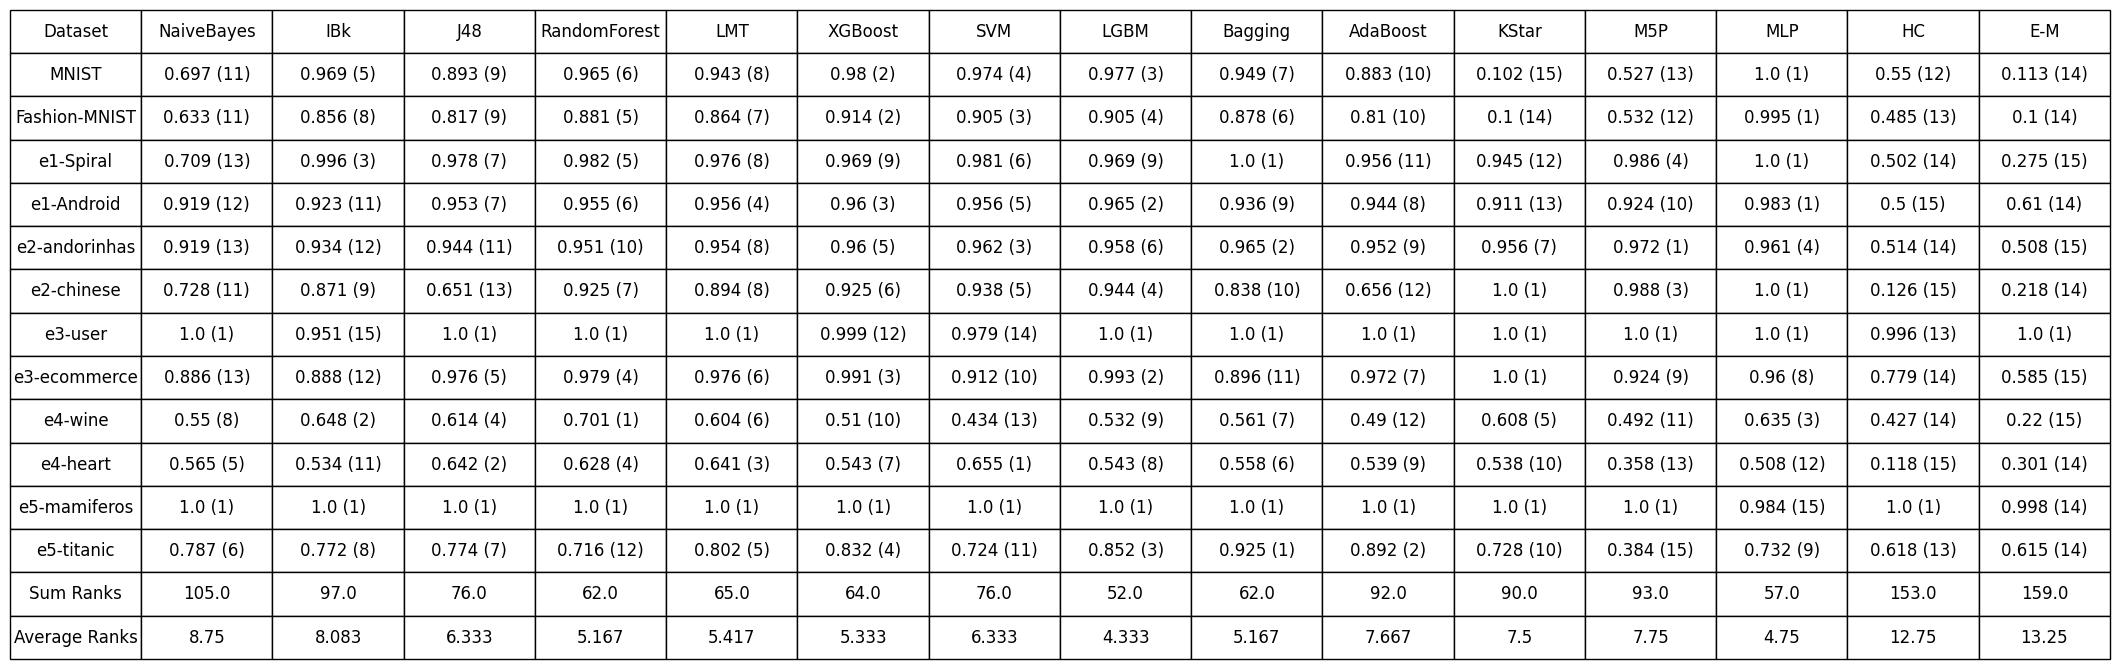

Table saved as 'table_with_rankings.png'
Friedman test statistic: 62.86301369863009, p-value = 3.6698419183447894e-08
Algorithms: ['NaiveBayes', 'IBk', 'J48', 'RandomForest', 'LMT', 'XGBoost', 'SVM', 'LGBM', 'Bagging', 'AdaBoost', 'KStar', 'M5P', 'MLP', 'HC', 'E-M']
Errors: [[0.6966   0.9691   0.8933   0.9649   0.943    0.9795   0.9739   0.9774
  0.9493   0.8826   0.102    0.5269   1.       0.5504   0.1135  ]
 [0.6328   0.8565   0.8173   0.8808   0.8638   0.9142   0.9053   0.905
  0.878    0.81     0.1      0.5322   0.9948   0.4855   0.1     ]
 [0.70875  0.9962   0.9775   0.9825   0.97625  0.9688   0.9812   0.9688
  1.       0.9563   0.9449   0.9857   1.       0.5025   0.275   ]
 [0.918683 0.922715 0.952509 0.954525 0.956317 0.9597   0.9563   0.9653
  0.9362   0.944    0.9106   0.9239   0.9833   0.5002   0.6105  ]
 [0.919    0.9335   0.944    0.951    0.954    0.96     0.9625   0.9575
  0.965    0.9525   0.9564   0.9715   0.9608   0.514    0.5075  ]
 [0.728411 0.871089 0.650814 0.92490

<Figure size 1600x1200 with 0 Axes>

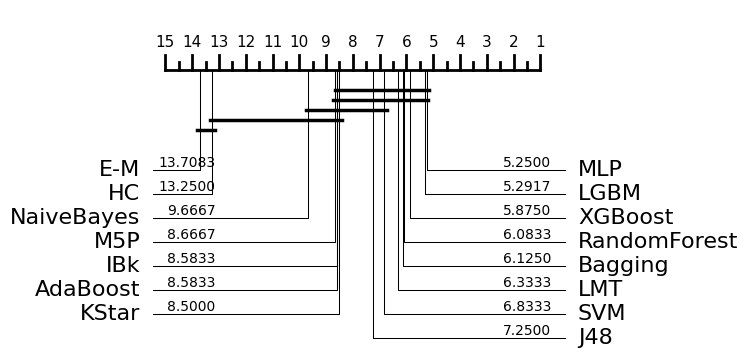

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import friedmanchisquare
from aeon.visualisation import plot_critical_difference

data = {
    'Datasets': [
      'MNIST', 'Fashion-MNIST', 
      'e1-Spiral', 'e1-Android',
      'e2-andorinhas', 'e2-chinese',
      'e3-user', 'e3-ecommerce',
      'e4-wine', 'e4-heart',
      'e5-mamiferos', 'e5-titanic'
    ],
    'Algorithms': [
        'NaiveBayes', 'IBk', 'J48', 'RandomForest', 'LMT', 
        'XGBoost', 'SVM', 'LGBM', 'Bagging', 'AdaBoost', 
        'KStar', 'M5P', 'MLP', 'HC', 'E-M'
    ],
    'Performance (Error)': [
        [ # MNIST -ok
            '30.34%', '3.09%', '10.67%', '3.51%', '5.70%', 
            '2.05%', '2.61%', '2.26%', '5.07%', '11.74%', 
            '89.80%', '47.31%', '0%', '44.96%', '88.65%'
        ],
        [ # Fashion-MNIST -ok
            '36.72%', '14.35%', '18.27%', '11.92%', '13.62%', 
            '8.58%', '9.47%', '9.50%', '12.20%', '19.00%',
            '90%', '46.78%', '0.52%', '51.45%', '90%'
        ],
        [ # e1-Spiral -ok
            '29.125%', '0.38%', '2.25%', '1.75%', '2.375%',
            '3.12%', '1.88%', '3.12%', '0%', '4.37%',
            '5.51%', '1.43%', '0%', '49.75%', '72.50%'
        ],
        [ # e1-Android -ok
            '8.1317%', '7.7285%', '4.7491%', '4.5475%', '4.3683%',
            '4.03%', '4.37%', '3.47%', '6.38%', '5.60%', 
            '8.94%', '7.61%', '1.67%', '49.98%', '38.95%'
        ],
        [   '8.1%', '6.65%', '5.60%', '4.90%', '4.60%', 
            '4.00%', '3.75%', '4.25%', '3.50%', '4.75%',
            '4.36%', '2.85%', '3.92%', '48.60%', '49.25%'
        ],
        [ # e2-chinese -ok
            '27.1589%', '12.8911%', '34.9186%', '7.5094%', '10.6383%',
            '7.50%', '6.25%', '5.63%', '16.25%', '34.38%', 
            '0%', '1.21%', '0%', '87.36%', '78.22%'
        ],
        [   '0%', '4.8571%', '0%', '0%', '0%', '0.1429%',
            '2.14%', '0%', '0%', '0%', '0%', '0%',
            '0%', '0.39%', '0%', '79.14%', '4.57%'
        ],
        [ # e3-ecommerce -ok
            '11.37%', '11.15%', '2.39%', '2.07%', '2.42%', 
            '0.90%', '8.80%', '0.70%', '10.35%', '2.85%', 
            '0.02%', '7.56%', '3.96%', '22.11%', '41.49%'
        ],
        [ # e4-wine -ok
            '44.96%', '35.21%', '38.59%', '29.89%', '39.65%',
            '48.95%', '56.56%', '46.85%', '43.94%', '50.99%', 
            '39.23%', '50.82%', '36.51%', '57.34%', '77.98%'
        ],
        [ # e4-heart -ok
            '43.51%', '46.61%', '35.82%', '37.20%', '35.88%',
            '45.71%', '34.51%', '45.73%', '44.16%', '46.1%', 
            '46.15%', '64.18%', '49.22%', '88.1962%', '69.94%'
        ],
        [ # e5-mamiferos -ok
            '0%', '0%', '0%', '0%', '0%', '0%',
            '0%', '0%', '0%', '0%', '0%', '0%',
            '1.57%', '0%', '0.20%', '31.20%', '44.80%'
        ],
        [ # e5-titanic -ok
            '21.3244%', '22.7834%', '22.5589%', '28.3951%', '19.7531%', 
            '16.76%', '27.56%', '14.85%', '7.48%', '10.79%', 
            '27.18%', '61.62%', '26.76%', '38.16%', '38.50%'
        ]
    ]
}

# Convert the data into a DataFrame
datasets = data['Datasets']
algorithms = data['Algorithms']
performance_data = data['Performance (Error)']

# Create a list of dictionaries for each dataset
rows = []
for dataset, performance in zip(datasets, performance_data):
    row = {'Dataset': dataset}
    row.update({alg: perf for alg, perf in zip(algorithms, performance)})
    rows.append(row)

# Create the DataFrame
df = pd.DataFrame(rows)

# Convert string percentages to floats
for alg in algorithms:
    df[alg] = df[alg].str.replace(',', '.').str.rstrip('%').astype(float) / 100
    # Convert to accuracy
    df[alg] = 1 - df[alg]

# Calculate the ranking of each algorithm for each dataset (higher accuracy = better rank)
rankings_matrix = df[algorithms].rank(axis=1, method="min", ascending=False)

# Format the results
formatted_results = df[algorithms].copy()
for col in formatted_results.columns:
    formatted_results[col] = formatted_results[col].round(3).astype(str) + " (" + rankings_matrix[col].astype(int).astype(str) + ")"

# Add a row for the sum of ranks and average of ranks
sum_ranks = rankings_matrix.sum().round(3).rename('Sum Ranks')
average_ranks = rankings_matrix.mean().round(3).rename('Average Ranks')

# Add the rows to the formatted DataFrame using concat
formatted_results = pd.concat([formatted_results, sum_ranks.to_frame().T, average_ranks.to_frame().T])

# Add the 'Dataset' column to the formatted DataFrame
formatted_results.insert(0, 'Dataset', df['Dataset'].tolist() + ['Sum Ranks', 'Average Ranks'])

# Display the table
print("Error Table (%) with Ranking:")
print(formatted_results)

# Save the formatted table as an image
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=formatted_results.values, colLabels=formatted_results.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(2.5, 2.5)
plt.subplots_adjust(left=0.2, bottom=0.2, right=0.8, top=1, wspace=0.2, hspace=0.2)
plt.savefig('table_with_rankings.png', format="png", bbox_inches="tight", dpi=300)
plt.show()

print("Table saved as 'table_with_rankings.png'")

# Perform the Friedman Test
friedman_stat, p_value = friedmanchisquare(*rankings_matrix.T.values)
print(f"Friedman test statistic: {friedman_stat}, p-value = {p_value}")

# Convert the accuracy matrix into a NumPy array for the critical difference diagram
scores = df[algorithms].values
classifiers = df[algorithms].columns.tolist()

print("Algorithms:", classifiers)
print("Errors:", scores)

# Set the figure size before plotting
plt.figure(figsize=(16, 12))  # Adjust the figure size as needed

# Generate the critical difference diagram
plot_critical_difference(
    scores, 
    classifiers, 
    lower_better=False, # in accuracy, higher is better
    test='wilcoxon',  # or nemenyi
    correction='holm', # or bonferroni or none
)

# Get the current axes
ax = plt.gca()

# Adjust font size and rotation of x-axis labels
for label in ax.get_xticklabels():
    label.set_fontsize(14) 
    label.set_rotation(45) 
    label.set_horizontalalignment('right')

# Increase padding between labels and axis
ax.tick_params(axis='x', which='major', pad=20)

# Adjust margins to provide more space for labels
plt.subplots_adjust(bottom=0.35)

# Optionally adjust y-axis label font size
ax.tick_params(axis='y', labelsize=12)

# Save and display the plot
plt.savefig('critical_difference_diagram.png', format="png", bbox_inches="tight", dpi=300)
plt.show()